# E56 · Sizer, adder or timer? How bacteria control their size, and how noisy measurements answer the question wrongly

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: Tanouchi et al. (2017), *Scientific Data* 4:170036 - mother-machine time-lapse of *E. coli* MC4100 in LB at 25, 27 and 37 °C, one frame per minute, 279 mother cells followed for about 70 generations each (about 19,000 cell cycles). Figshare, CC0 |
| **You will learn** | Exponential single-cell growth and the three classic **division rules** (sizer, adder, timer) · the **noisy linear map** $S_d = a S_b + b + \xi$ and why size homeostasis needs $a < 2$ · birth size along a lineage as an **AR(1) process** · **regression dilution**: measurement error in birth size biases the slope towards 0, i.e. towards "sizer", and the division-birth difference towards a negative correlation · an **errors-in-variables lineage model**: a closed-form 16-dimensional multivariate normal for eight consecutive generations, in which the lineage's own autocorrelation identifies the measurement noise · a stress test on real data (add known noise: the naive answer moves a lot, the latent-variable answer much less) and an **over-correction** check · sizer vs adder vs timer by **PSIS-LOO** over lineage windows · **posterior predictive checks** of the adder's other predictions · **hierarchical growth rates** across lineages, and why fast growers have short cell cycles |

## How does a cell know when to divide?

A bacterium in a steady environment grows exponentially: its length increases by the same
fraction every minute. If it divided at a random moment, its size would drift without bound over
the generations; in reality cells of one strain in one medium keep a remarkably constant size.
So each cell must, somehow, decide *when* to divide based on something it can sense. Three
simple rules have been proposed. A **sizer** divides when it reaches a set size, whatever size it
was born at. A **timer** divides a fixed time after birth. An **adder** divides after adding a
fixed length $\Delta$ since birth, whatever its birth size (Campos et al. 2014, *Cell*, in
*Caulobacter* and *E. coli*; Taheri-Araghi et al. 2015, *Current Biology*, in *E. coli* and
*B. subtilis* across growth conditions). The three rules make different predictions for one
simple plot: size at division against size at birth. A sizer gives a flat line, an adder a line of
slope 1, a timer a line of slope about 2.

The catch is that birth size is *measured*, from segmented microscope images, and the
measurement has errors. A classic statistical fact, **regression dilution**, says that noise in
the x-variable flattens a regression slope. Noisy birth sizes therefore make every rule look more
like a sizer than it is. This notebook fits the division rule to a long mother-machine dataset,
estimates the measurement noise from the lineages themselves, and shows how much the answer moves
when the noise is modelled - and how badly it would move with noisier images.

## The plan

1. Three division rules and the noisy linear map
2. Regression dilution: why noisy sizes make every cell look like a sizer
3. The data: 279 mother cells, 19,000 cell cycles
4. The naive answer
5. How noisy is a single length measurement?
6. An errors-in-variables model for eight generations at a time
7. A stress test: add known noise to the real data
8. Sizer, adder or timer? LOO over lineage windows
9. Checking the adder's other predictions
10. Growth-rate variability: lineages, partial pooling, and why fast growers divide early

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr

from pymc_challenges import data

RANDOM_SEED = 56
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
TEMPS = [25, 27, 37]
TCOL = {25: BLUE, 27: AQUA, 37: ORANGE}
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · Three division rules and the noisy linear map

Let $S_b$ be a cell's size (here: length) at birth and $S_d$ its size at division. Within a
cycle it grows exponentially at rate $\lambda$, so after a generation time $\tau$,
$S_d = S_b\, e^{\lambda \tau}$. A division rule is a relation between $S_d$ and $S_b$. A
convenient family that contains all three rules is the **noisy linear map** (Amir 2014, *PRL*;
Tanouchi et al. 2015, *Nature*):

$$S_d = a\, S_b + b + \xi, \qquad \xi \sim \text{Normal}(0, \sigma_\xi),$$

- **sizer**: $a = 0$, divide at $b$ on average whatever the birth size;
- **adder**: $a = 1$, add $\Delta = b$ on average: $S_d - S_b$ does not depend on $S_b$;
- **timer**: $a = e^{\lambda\tau} \approx 2$, divide after a fixed time: $S_d \propto S_b$.

At division the cell splits into two, and the daughter we follow is born at
$S_b' = f\, S_d$ with $f \approx 1/2$ (plus some noise $\zeta$). Put together,

$$S_b' = f a\, S_b + f b + f \xi + \zeta,$$

which is an **AR(1) process** for birth size along a lineage, with autoregressive coefficient
$fa$. It is stable, i.e. sizes stay bounded (**size homeostasis**), only if $fa < 1$: for
symmetric division, $a < 2$. A timer sits exactly at the boundary, so under a timer birth size is
a random walk: a cell born big stays big, and its descendants' sizes wander without limit. Three
consequences we will use:

1. the slope of $S_d$ on $S_b$ is $a$;
2. under an adder, the added size $\Delta = S_d - S_b$ is uncorrelated with $S_b$;
3. the correlation of birth sizes $k$ generations apart decays as $(fa)^k$ - for an adder with
   symmetric division, 0.5, 0.25, 0.125, ...

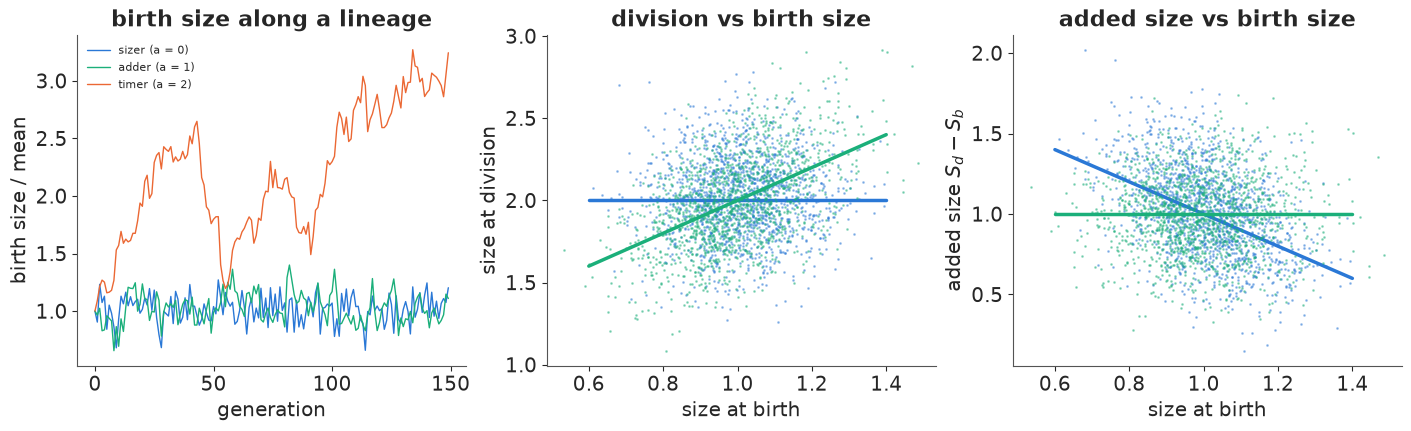

In [2]:
def simulate_linear_map(a, n_gen, rng, f=0.5, sd_xi=0.24, sd_zeta=0.02, sb0=1.0):
    """One lineage of the noisy linear map, sizes in units of the mean birth size (for a < 2)."""
    b = (1 / f - a) * 1.0                                        # makes the mean birth size 1
    sb = np.empty(n_gen); sd = np.empty(n_gen); s = sb0
    for n in range(n_gen):
        sb[n] = s
        sd[n] = a * s + b + sd_xi * rng.normal()
        s = f * sd[n] + sd_zeta * rng.normal()
    return sb, sd


sim_rng = np.random.default_rng(RANDOM_SEED)
rules = {"sizer (a = 0)": (0.0, BLUE), "adder (a = 1)": (1.0, AQUA), "timer (a = 2)": (2.0, ORANGE)}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for label, (a, col) in rules.items():
    sb, sd = simulate_linear_map(a, 3000, sim_rng)
    axes[0].plot(sb[:150], color=col, lw=1, label=label)
    if a < 2:
        axes[1].plot(sb[:1500], sd[:1500], ".", ms=2, color=col, alpha=0.4)
        axes[2].plot(sb[:1500], sd[:1500] - sb[:1500], ".", ms=2, color=col, alpha=0.4)
        xx = np.array([0.6, 1.4])
        axes[1].plot(xx, a * xx + (2 - a), color=col, lw=2.5)      # the rule's mean line
        axes[2].plot(xx, (a - 1) * xx + (2 - a), color=col, lw=2.5)
axes[0].set(xlabel="generation", ylabel="birth size / mean", title="birth size along a lineage")
axes[0].legend(fontsize=8)
axes[1].set(xlabel="size at birth", ylabel="size at division", title="division vs birth size")
axes[2].set(xlabel="size at birth", ylabel="added size $S_d - S_b$", title="added size vs birth size");

Left: under a sizer and an adder, birth size fluctuates around its mean; under a timer (orange)
it wanders off: a random walk that, left alone, would end in minicells or filaments. Middle:
division size is flat in birth size for the sizer (blue; thick lines are the rules' mean lines)
and rises with slope 1 for the adder (green). Right: the adder's signature - the added size does
not depend on birth size - while a sizer's added size falls with slope -1. The clouds overlap a
lot: with realistic division noise, telling the rules apart takes many cycles.
Note also the spread of birth sizes: a sizer resets size every generation, so its birth sizes are
the tightest (sd $f\sigma_\xi$); an adder corrects only half of any deviation per generation,
so they are wider.

## 2 · Regression dilution: why noisy sizes make every cell look like a sizer

Now measure the sizes with error: $\tilde S_b = S_b + e_b$, $\tilde S_d = S_d + e_d$ with
independent errors of sd $\sigma_e$. Regressing $\tilde S_d$ on $\tilde S_b$ gives, for many cells,

$$\hat a \;\to\; a \cdot \frac{\operatorname{Var}(S_b)}{\operatorname{Var}(S_b) + \sigma_e^2} = a \cdot R,$$

where $R < 1$ is the **reliability** of the birth-size measurement. The noise in $\tilde S_d$ does
not bias the slope; the noise in $\tilde S_b$ always pulls it towards 0. And the added size gets
a second problem: $\tilde\Delta = \tilde S_d - \tilde S_b$ contains $-e_b$, the same error as
$\tilde S_b$ with the opposite sign, so $\operatorname{Cov}(\tilde S_b, \tilde\Delta) =
\operatorname{Cov}(S_b, \Delta) - \sigma_e^2$: even a perfect adder shows a **negative**
correlation between added size and birth size, which is exactly what a sizer-like correction
would look like. Both errors point the same way: towards "sizer".

true birth-size CV: 0.139; slope at 10% error: 0.66 (theory 0.66)


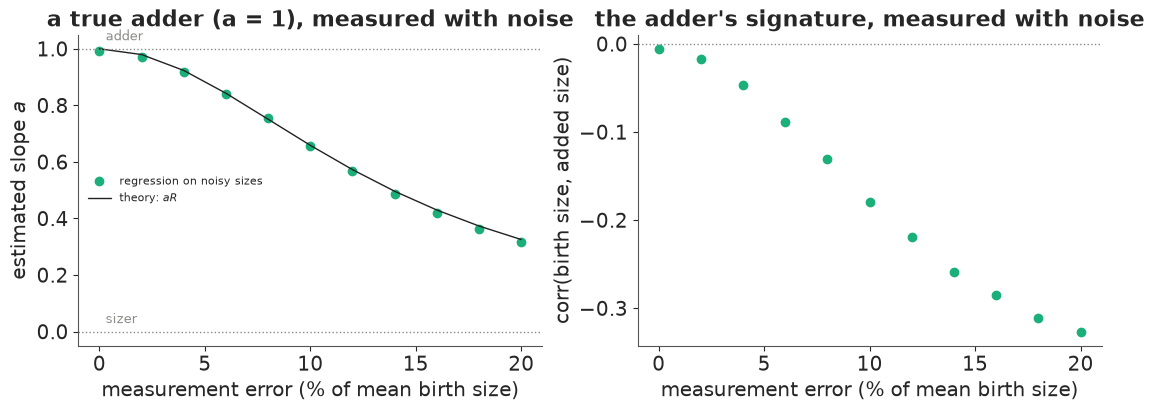

In [3]:
sb, sd = simulate_linear_map(1.0, 20000, np.random.default_rng(RANDOM_SEED + 1))
noise = np.linspace(0, 0.2, 11)                               # measurement sd / mean birth size
slope_hat, corr_hat = [], []
nrng = np.random.default_rng(RANDOM_SEED + 2)
for s in noise:
    sb_o = sb + s * nrng.normal(size=sb.size)
    sd_o = sd + s * 2 * nrng.normal(size=sd.size)             # same relative error at division
    slope_hat.append(np.polyfit(sb_o, sd_o, 1)[0])
    corr_hat.append(np.corrcoef(sb_o, sd_o - sb_o)[0, 1])
R_theory = sb.var() / (sb.var() + noise**2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(100 * noise, slope_hat, "o", color=AQUA, label="regression on noisy sizes")
axes[0].plot(100 * noise, R_theory, "-", color=INK, lw=1, label="theory: $a R$")
for y, lab in [(0, "sizer"), (1, "adder")]:
    axes[0].axhline(y, color=GREY, ls=":", lw=1)
    axes[0].text(0.3, y + 0.03, lab, color=GREY, fontsize=9)
axes[0].set(xlabel="measurement error (% of mean birth size)", ylabel="estimated slope $a$",
            title="a true adder (a = 1), measured with noise")
axes[0].legend(fontsize=8)
axes[1].plot(100 * noise, corr_hat, "o", color=AQUA)
axes[1].axhline(0, color=GREY, ls=":", lw=1)
axes[1].set(xlabel="measurement error (% of mean birth size)",
            ylabel="corr(birth size, added size)", title="the adder's signature, measured with noise")
print(f"true birth-size CV: {sb.std() / sb.mean():.3f}; slope at 10% error: {slope_hat[5]:.2f} "
      f"(theory {R_theory[5]:.2f})");

The simulated adder has a birth-size CV of about 14% (printed), about what real *E. coli* shows.
Measured with a 10% error, its estimated slope drops to about two thirds - halfway to "sizer" -
and the added size becomes clearly anti-correlated with birth size, although the cells follow a
perfect adder. The theory line $aR$ matches the simulation. Nothing about a bigger sample fixes
this: the bias is in the estimand, not in the variance. To fix it we have to model the true
sizes as unknowns and the measurements as noisy readings of them - an **errors-in-variables**
model - and that needs some information about how large the noise is.

## 3 · The data: 279 mother cells, 19,000 cell cycles

In a **mother machine** (Wang et al. 2010, *Current Biology*) bacteria grow in dead-end channels
of a microfluidic chip, and the cell at the closed end - the "mother", which keeps its old pole -
is trapped there for its whole life while its daughters are washed out of the channel. One mother
can be imaged for days. Tanouchi et al. (2017) published such movies and their analysis for
*E. coli* MC4100 in LB at 25, 27 and 37 °C: for each mother, its length (the long axis of the
segmented cell) every minute, and a flag at each division.

In [4]:
data.describe("tanouchi_mother_machine")
raw = np.load(data.path("tanouchi_mother_machine"))
LINEAGES = raw["lineage"].astype(str)
LIN_TEMP = raw["temp_c"].astype(int)


def lineage_trace(k):
    """(lengths, division frames) of lineage k."""
    L = raw["length_um"][raw["frame_offset"][k]: raw["frame_offset"][k + 1]].astype(float)
    div = raw["division_frame"][raw["division_offset"][k]: raw["division_offset"][k + 1]]
    return L, div


print({T: int((LIN_TEMP == T).sum()) for T in TEMPS}, "mother cells;",
      f"{raw['length_um'].size:,} length measurements")

tanouchi_mother_machine: NumPy .npz (open data.path(...) with np.load): mother-machine time-lapse of E. coli MC4100 (constitutive YFP) mother cells in LB at 25, 27 and 37 C, one frame per minute, about 70 generations per cell. lineage (279 names such as '37C_xy01_01'), temp_c; length_um (concatenated cell lengths, the major axis of the segmented mask, float32) with frame_offset (lineage k is length_um[frame_offset[k]:frame_offset[k+1]]); division_frame (frame indices, within the lineage, of the first frame after each detected division; the first entry is frame 0, the start of the recording) with division_offset; minutes_per_frame = 1.
  source: Tanouchi, Pai, Park, Huang, Buchler & You (2017), Long-term growth data of Escherichia coli at a single-cell level, Scientific Data 4:170036 (doi:10.1038/sdata.2017.36); data on figshare (collection 3493548, files released under CC0): 'Zipped analysis data files of mother cells cultured at 25C / 27C / 37C' (ndownloader.figshare.com/files/6397359

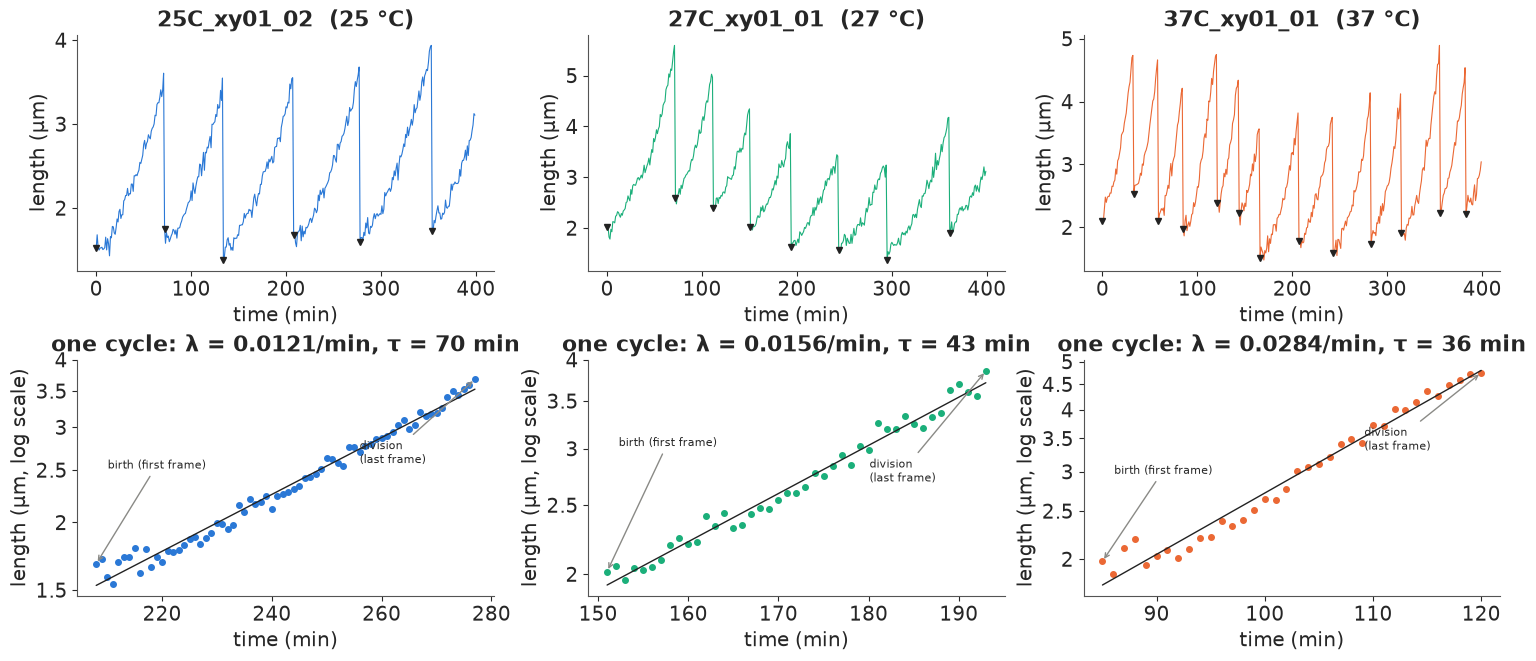

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.5), height_ratios=[1, 1])
for c, T in enumerate(TEMPS):
    k = int(np.flatnonzero(LIN_TEMP == T)[0])
    L, div = lineage_trace(k)
    t = np.arange(400)
    axes[0, c].plot(t, L[:400], color=TCOL[T], lw=0.8)
    axes[0, c].plot(div[div < 400], L[div[div < 400]], "v", color=INK, ms=4)
    axes[0, c].set(title=f"{LINEAGES[k]}  ({T} °C)", xlabel="time (min)", ylabel="length (µm)")
    # one cycle close up, on a log scale, with its exponential fit
    i, j = div[3], div[4]
    tt = np.arange(i, j)
    coef = np.polyfit(tt - i, np.log(L[i:j]), 1)
    axes[1, c].plot(tt, L[i:j], "o", color=TCOL[T], ms=4)
    axes[1, c].plot(tt, np.exp(np.polyval(coef, tt - i)), color=INK, lw=1)
    axes[1, c].set_yscale("log")
    ticks = np.arange(1.5, 6.0, 0.5)
    ticks = ticks[(ticks > 0.9 * L[i:j].min()) & (ticks < 1.1 * L[i:j].max())]
    axes[1, c].set_yticks(ticks, [f"{tk:g}" for tk in ticks])
    axes[1, c].yaxis.set_minor_formatter(plt.NullFormatter())
    axes[1, c].set(xlabel="time (min)", ylabel="length (µm, log scale)",
                   title=f"one cycle: λ = {coef[0]:.4f}/min, τ = {j - i} min")
    axes[1, c].annotate("birth (first frame)", (i, L[i]), (i + 0.03 * (j - i), L[i] * 1.5),
                        fontsize=8, arrowprops=dict(arrowstyle="->", color=GREY))
    axes[1, c].annotate("division\n(last frame)", (j - 1, L[j - 1]), (j - 1 - 0.3 * (j - i), L[j - 1] * 0.7),
                        fontsize=8, arrowprops=dict(arrowstyle="->", color=GREY))

Top: the first 400 minutes of one mother cell at each temperature, a saw-tooth of exponential
growth and halving (triangles: first frame after each detected division). The cycle is visibly
longer at 25 °C than at 37 °C. Bottom: one cycle on a log scale. Exponential growth is a straight
line, and it fits well, but single frames scatter around it by a few percent (segmenting a
2-5 µm cell from a fluorescence image is not more precise). "Birth size" is read off the first frame after a
division and "division size" off the last frame before it, so each carries this frame-level
error. (In all three examples the first frame sits a little above the fitted line. A constant
proportional offset like that shifts the intercept of the linear map on the log scale, not its
slope.)

The per-cycle table: for each cycle between two divisions we record the first and last length,
the generation time, and the exponential growth rate fitted to all frames. The first cycle of
each movie starts at the beginning of the recording, not at a birth, and is dropped. Some cycles
are aberrant: filaments that fail to divide, mis-segmented frames, missed divisions. We flag a
cycle as aberrant if its log birth or division length is more than 4 robust sds (4 × 1.48 × MAD)
from its temperature's median, or its within-cycle scatter around the exponential fit exceeds
10%.

In [6]:
def cycle_table():
    rows = []
    for k in range(len(LINEAGES)):
        L, div = lineage_trace(k)
        for c, (i, j) in enumerate(zip(div[:-1], div[1:])):
            if c == 0:
                continue                                      # the recording starts mid-cycle
            t = np.arange(j - i); y = np.log(L[i:j])
            coef = np.polyfit(t, y, 1)
            resid = y - np.polyval(coef, t)
            rows.append((LINEAGES[k], LIN_TEMP[k], c, j - i, L[i], L[j - 1], L[j], coef[0],
                         resid.std(ddof=2) if j - i > 3 else np.nan))
    return pd.DataFrame(rows, columns=["lineage", "temp", "cycle", "gen_time", "Lb", "Ld",
                                       "L_next", "lam", "frame_sd"])


cycles = cycle_table()
ok = cycles["frame_sd"] < 0.1
for col in ["Lb", "Ld"]:
    x = np.log(cycles[col])
    dev = x - x.groupby(cycles["temp"]).transform("median")
    mad = dev.abs().groupby(cycles["temp"]).transform("median") * 1.4826
    ok &= dev.abs() < 4 * mad
cycles["ok"] = ok
summary = cycles[cycles["ok"]].groupby("temp").agg(
    cycles=("Lb", "size"), birth_um=("Lb", "mean"), birth_cv=("Lb", lambda x: x.std() / x.mean()),
    division_um=("Ld", "mean"), gen_time_min=("gen_time", "mean"), lam_per_min=("lam", "mean"),
    frame_sd=("frame_sd", "median"))
summary["flagged_%"] = 100 * (1 - cycles.groupby("temp")["ok"].mean())
summary["doubling_min"] = np.log(2) / summary["lam_per_min"]
summary["f = L_next/Ld"] = (cycles[cycles["ok"]]["L_next"] / cycles[cycles["ok"]]["Ld"]).groupby(
    cycles["temp"]).median()
print(f"{len(cycles):,} complete cycles")
summary.round(3)

18,972 complete cycles


,cycles,birth_um,birth_cv,division_um,gen_time_min,lam_per_min,frame_sd,flagged_%,doubling_min,f = L_next/Ld
temp,,,,,,,,,,
25,4343,2.042,0.247,4.440,67.589,0.012,0.034,1.742,57.158,0.458
27,3543,1.672,0.150,3.619,53.273,0.015,0.042,3.513,46.647,0.460
37,10541,2.077,0.135,4.462,32.464,0.025,0.036,3.116,27.415,0.463


Between 2 and 4% of cycles are flagged at each temperature. Cells grow almost twice as fast at 37 °C
(doubling in about 27 minutes) as at 25 °C (about 57 minutes), and the mean generation time
follows (a little longer than the doubling time, because the mother gets less than half at
division - see below). Birth sizes vary by 13-25% (CV) between cycles. The median within-cycle
frame scatter is 3-4% of the length. The last column is the ratio of the first length after a
division to the last length before it: 0.46, not 0.5. Part of that is real (the old-pole mother
can be born slightly smaller than her sister), part may be the segmentation of a constricting
cell; either way it is the $f$ of the linear map for these measurements, and we will estimate it.

## 4 · The naive answer

The standard analysis bins cycles by birth size and plots the mean division size and added size
in each bin.

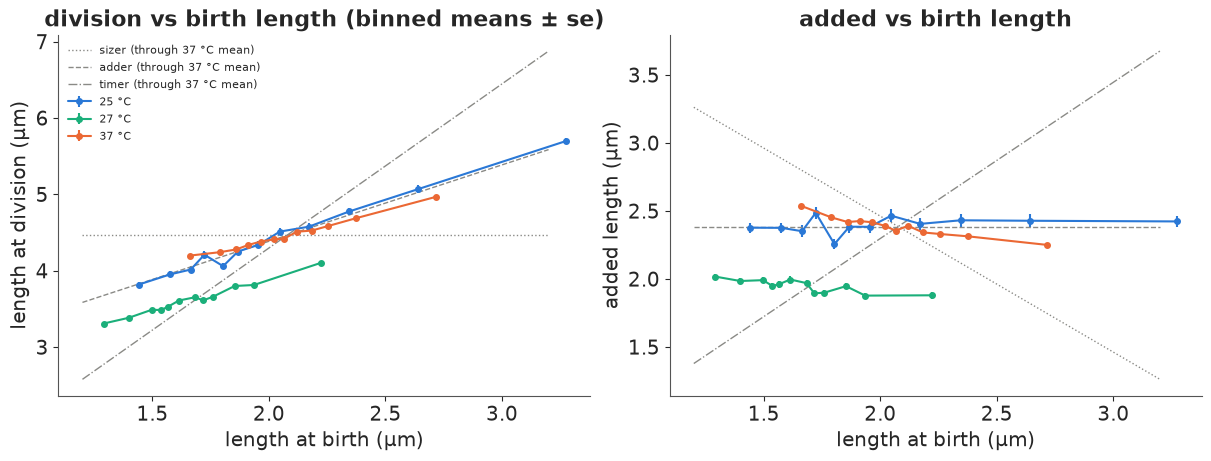

In [7]:
good = cycles[cycles["ok"]]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for T in TEMPS:
    g = good[good["temp"] == T]
    bins = np.quantile(g["Lb"], np.linspace(0, 1, 13))
    grp = g.groupby(pd.cut(g["Lb"], bins, include_lowest=True), observed=True)
    xb = grp["Lb"].mean(); n = grp.size()
    for ax, y in zip(axes, [grp["Ld"], (g["Ld"] - g["Lb"]).groupby(pd.cut(g["Lb"], bins,
                                                                          include_lowest=True),
                                                                   observed=True)]):
        ax.errorbar(xb, y.mean(), yerr=y.std() / np.sqrt(n), fmt="o-", color=TCOL[T], ms=4,
                    label=f"{T} °C")
x0 = np.array([1.2, 3.2])
g37 = good[good["temp"] == 37]
mb, md = g37["Lb"].mean(), g37["Ld"].mean()
for a, lab, ls in [(0, "sizer", ":"), (1, "adder", "--"), (md / mb, "timer", "-.")]:
    axes[0].plot(x0, md + a * (x0 - mb), ls, color=GREY, lw=1, label=f"{lab} (through 37 °C mean)")
    axes[1].plot(x0, (md - mb) + (a - 1) * (x0 - mb), ls, color=GREY, lw=1)
axes[0].set(xlabel="length at birth (µm)", ylabel="length at division (µm)",
            title="division vs birth length (binned means ± se)")
axes[1].set(xlabel="length at birth (µm)", ylabel="added length (µm)", title="added vs birth length")
axes[0].legend(fontsize=8);

The binned means lie between the sizer and adder guides at 27 and 37 °C and close to the adder
at 25 °C; the added length falls with birth size at 37 °C, slightly at 27 °C, and is nearly flat
at 25 °C. Read naively: an adder at 25 °C, a mixture of adder and sizer ("sizer-like") at 37 °C.

Now the same as a Bayesian regression. We work with **log lengths**, $y = \log S$, for the rest
of the notebook: the segmentation error is roughly a fixed *fraction* of the length (additive on
the log scale), and log lengths have lighter tails. On the log scale the linear map becomes
$\log S_d = \alpha \log S_b + c + \xi$, and linearising around the mean gives
$\alpha = a\, \bar S_b / \bar S_d = a f$ (in steady state $\bar S_b = f \bar S_d$). So

$$a = \alpha / f: \qquad \text{sizer } \alpha = 0, \quad \text{adder } \alpha = f \approx 0.46, \quad \text{timer } \alpha = 1\ (a = 1/f \approx 2.2).$$

To compare like with like, all models from here on use the same cycles: runs of **eight
consecutive unflagged generations** of one mother ("windows"), which section 6 needs.

In [8]:
NW = 8                                                         # generations per window


def make_windows(cyc, nw=NW):
    """Non-overlapping runs of nw consecutive unflagged cycles: rows [b1, d1, b2, d2, ...] (log)."""
    Y, T, L = [], [], []
    for lin, h in cyc.groupby("lineage", sort=False):
        h = h.sort_values("cycle")
        okh = h["ok"].to_numpy()
        yb, yd = np.log(h["Lb"].to_numpy()), np.log(h["Ld"].to_numpy())
        for s in range(0, len(h) - nw + 1, nw):
            if okh[s:s + nw].all() and np.all(np.diff(h["cycle"].to_numpy()[s:s + nw]) == 1):
                Y.append(np.column_stack([yb[s:s + nw], yd[s:s + nw]]).ravel())
                T.append(h["temp"].iloc[0]); L.append(lin)
    return np.array(Y), np.searchsorted(TEMPS, T), np.array(L)


Y, ti, win_lineage = make_windows(cycles)
YB, YD = Y[:, 0::2], Y[:, 1::2]
FHAT = np.array([np.exp(np.mean(Y[ti == t][:, 2::2] - Y[ti == t][:, 1:-1:2])) for t in range(3)])
print(f"{len(Y):,} windows ({len(Y) * NW:,} cycles):", dict(zip(TEMPS, np.bincount(ti).tolist())))
print("f (geometric mean of next birth / division):", dict(zip(TEMPS, FHAT.round(3).tolist())))
naive_ols = {T: float(np.polyfit(YB[ti == t].ravel(), YD[ti == t].ravel(), 1)[0] / FHAT[t])
             for t, T in enumerate(TEMPS)}
naive_all = {T: float(np.polyfit(np.log(good[good.temp == T]["Lb"]), np.log(good[good.temp == T]["Ld"]),
                           1)[0] / FHAT[t]) for t, T in enumerate(TEMPS)}
print("least-squares a, window cycles:", {T: round(v, 3) for T, v in naive_ols.items()})
print("least-squares a, all unflagged cycles:", {T: round(v, 3) for T, v in naive_all.items()})

1,944 windows (15,552 cycles): {25: 474, 27: 371, 37: 1099}
f (geometric mean of next birth / division): {25: 0.456, 27: 0.458, 37: 0.461}
least-squares a, window cycles: {25: 1.09, 27: 0.846, 37: 0.752}
least-squares a, all unflagged cycles: {25: 1.096, 27: 0.854, 37: 0.77}


The windows keep about 80% of the cycles. Least squares gives the same slopes on the window
cycles and on all unflagged cycles (printed; within about 0.03), so the window selection does not
move the naive answer much. The Bayesian version of the naive regression:

In [9]:
def naive_model(Y, ti):
    yb, yd = Y[:, 0::2].ravel(), Y[:, 1::2].ravel()
    tr = np.repeat(ti, NW)
    with pm.Model(coords={"temp": TEMPS}) as m:
        alpha = pm.Normal("alpha", 0.5, 0.3, dims="temp")
        c = pm.Normal("c", 1.0, 0.5, dims="temp")
        sigma = pm.HalfNormal("sigma", 0.2, dims="temp")
        pm.Normal("yd", alpha[tr] * yb + c[tr], sigma[tr], observed=yd)
        pm.Deterministic("a", alpha / FHAT, dims="temp")
    return m


def fit(model, label, **kw):
    t0 = time.time()
    idata = pm.sample(model=model, random_seed=RANDOM_SEED, progressbar=False, **kw)
    print(f"{label}: {time.time() - t0:.0f} s, {int(idata.sample_stats['diverging'].sum())} "
          f"divergences, {idata.posterior.attrs.get('tuning_steps')} tuning steps (nutpie)")
    return idata


idata_naive = fit(naive_model(Y, ti), "naive regression")
az.summary(idata_naive, var_names=["a", "sigma"], round_to=3)

naive regression: 6 s, 0 divergences, 400 tuning steps (nutpie)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a[25],1.090,0.027,1.048,1.133,1833.428,2084.921,1.002,0.001,0.000
a[27],0.848,0.028,0.803,0.890,1636.585,1883.952,1.001,0.001,0.001
a[37],0.753,0.017,0.725,0.780,1199.112,1205.917,1.002,0.000,0.000
sigma[25],0.163,0.002,0.160,0.166,5122.462,2797.072,1.000,0.000,0.000
sigma[27],0.098,0.001,0.096,0.100,5077.263,2856.913,1.002,0.000,0.000
sigma[37],0.090,0.001,0.089,0.091,4828.074,2884.415,1.001,0.000,0.000


Sampling is instant and clean (r_hat 1.00). The naive posterior is **precise**: $a$ is about 1.09
at 25 °C, 0.85 at 27 °C and 0.75 at 37 °C, each with an sd of 0.02-0.03. With thousands of
cycles the naive answer is confident. Whether it is *right* depends on how noisy the birth
lengths are.

## 5 · How noisy is a single length measurement?

Every cycle has 20-100 frames on an exponential curve, so the scatter of the frames around the
fitted line (the `frame_sd` column) is a direct look at measurement error. Its median is 3-4% of
the length. If this were the error of the birth and division lengths, the reliability of log
birth length would be

In [10]:
for t, T in enumerate(TEMPS):
    v = YB[ti == t].var()
    e2 = cycles.loc[cycles["ok"] & (cycles.temp == T), "frame_sd"].median() ** 2
    print(f"{T} °C: var(log birth length) = {v:.4f}, frame scatter^2 = {e2:.5f}, "
          f"R = {(v - e2) / v:.3f}")

25 °C: var(log birth length) = 0.0472, frame scatter^2 = 0.00116, R = 0.975
27 °C: var(log birth length) = 0.0194, frame scatter^2 = 0.00174, R = 0.910
37 °C: var(log birth length) = 0.0150, frame scatter^2 = 0.00132, R = 0.912


a reliability of 0.91-0.98: the naive slopes would be 2-9% too flat. That is a useful first
estimate, but not a safe one. The frame scatter mixes segmentation error with real departures
from a perfect exponential (growth is not exactly exponential within a cycle, and the cell's
outline changes as it constricts), and the first and last frames of a cycle, next to a division,
may be worse or better than the average frame. We would rather let the **lineages** tell us the
error of the numbers we actually regress.

## 6 · An errors-in-variables model for eight generations at a time

Write $b_n, d_n$ for the true log lengths at birth and division in generation $n$ of a window,
and $\tilde b_n, \tilde d_n$ for the measured ones:

$$d_n = \alpha\, b_n + c + \xi_n, \qquad b_{n+1} = d_n + \varphi + \zeta_n, \qquad
\tilde b_n = b_n + e_{b,n}, \quad \tilde d_n = d_n + e_{d,n},$$

with $\xi_n \sim N(0, \sigma_\xi)$ (division noise), $\zeta_n \sim N(0, \sigma_\zeta)$
(partition noise, $\varphi = \log f$), measurement errors $e \sim N(0, \kappa)$, a window-level
intercept $c \sim N(\mu_c, s_c)$ (slow drift and differences between mothers) and a first birth
size $b_1 \sim N(m_0, s_0)$. Everything is linear and Gaussian, so the 16 measurements of a
window are **one multivariate normal** whose mean and covariance we can write down: each true
log length is a linear combination $A$ of the 17 independent inputs ($b_1$, $c$, eight $\xi$,
seven $\zeta$), and

$$\tilde y \sim \text{MvNormal}\big(\mu(\theta),\; A(\theta)\, D(\theta)\, A(\theta)^\top + \kappa^2 I\big).$$

The true sizes are integrated out exactly, with no latent variables to sample. Why is $\kappa$
identifiable at all? Because the lineage has **memory**. Measurement error is independent from
frame to frame, while the true birth sizes of successive generations are correlated (the AR(1)
of section 1: correlation $\alpha$ per generation on the log scale). Covariances between
different generations contain no measurement error; the variance of each single measurement
does. The gap between the two is $\kappa^2$. The windows are treated as independent: they
ignore the correlation between the end of one window and the start of the next (0.3-0.5 per
generation, fading within a few generations), a small loss of information.

(A Kalman filter along whole lineages is the other exact route; written as a `scan` in PyTensor
it was several times slower when we tried it, so we use windows. See exercise 1.)

In [11]:
def window_moments(alpha, phi, sxi, szeta, kappa, muc, sc, m0, s0, nw=NW):
    """Mean (2nw,) and covariance (2nw, 2nw) of the measured [b1, d1, b2, d2, ...] in a window."""
    q = 2 + nw + nw - 1                                        # inputs: b1, c, xi_1..nw, zeta_1..nw-1

    def unit(i):
        return pt.set_subtensor(pt.zeros(q)[i], 1.0)

    scale = pt.concatenate([pt.stack([s0, sc]), pt.repeat(sxi, nw), pt.repeat(szeta, nw - 1)])
    rows, means = [], []
    b, mb = unit(0), m0
    for k in range(nw):
        d = alpha * b + unit(1) + unit(2 + k)
        md = alpha * mb + muc
        rows += [b, d]; means += [mb, md]
        if k < nw - 1:
            b, mb = d + unit(2 + nw + k), md + phi
    A = pt.stack(rows) * scale[None, :]
    return pt.stack(means), A @ A.T + kappa**2 * pt.eye(2 * nw)


def eiv_model(Y, ti, rule="free", kappa_fixed=None):
    """Errors-in-variables linear map for NW-generation windows, one set of parameters per temp."""
    with pm.Model(coords={"temp": TEMPS}) as m:
        phi = pm.Normal("phi", np.log(0.5), 0.1, dims="temp")
        if rule == "free":
            alpha_pop = pm.Normal("alpha_pop", 0.5, 0.3)
            s_alpha = pm.HalfNormal("s_alpha", 0.2)
            alpha = pm.Normal("alpha", alpha_pop, s_alpha, dims="temp")
        else:                                                  # fixed rules
            val = {"sizer": np.zeros(3), "adder": FHAT, "timer": np.ones(3)}[rule]
            alpha = pm.Deterministic("alpha", pt.as_tensor(val), dims="temp")
        sxi = pm.HalfNormal("sxi", 0.2, dims="temp")
        szeta = pm.HalfNormal("szeta", 0.2, dims="temp")
        if kappa_fixed is None:
            kappa = pm.Gamma("kappa", 2.0, 50.0, dims="temp")     # mode 2%, mean 4%
        else:
            kappa = pt.as_tensor(np.full(3, kappa_fixed))
        muc = pm.Normal("muc", 1.0, 0.5, dims="temp")
        sc = pm.Gamma("sc", 2.0, 50.0, dims="temp")
        m0 = pm.Normal("m0", 0.7, 0.3, dims="temp")
        s0 = pm.HalfNormal("s0", 0.3, dims="temp")
        pm.Deterministic("a", alpha * pt.exp(-phi), dims="temp")
        for t, T in enumerate(TEMPS):
            mu, cov = window_moments(alpha[t], phi[t], sxi[t], szeta[t], kappa[t], muc[t], sc[t],
                                     m0[t], s0[t])
            pm.MvNormal(f"y{T}", mu, cov, observed=Y[ti == t])
    return m


m_free = eiv_model(Y, ti)
prior = pm.sample_prior_predictive(model=m_free, draws=500, random_seed=RANDOM_SEED)
pa = prior.prior["a"].values.reshape(-1, 3)[:, 2]
pyb = np.exp(prior.prior_predictive["y37"].values[0, :, :, 0].ravel())
print(f"prior a (37 °C): 5-95% {np.quantile(pa, 0.05):.2f} to {np.quantile(pa, 0.95):.2f}; "
      f"prior birth lengths: 5-95% {np.quantile(pyb, 0.05):.2f} to {np.quantile(pyb, 0.95):.1f} µm")

prior a (37 °C): 5-95% -0.17 to 2.30; prior birth lengths: 5-95% 1.02 to 4.0 µm


The prior predictive is deliberately wide: the prior slope ranges from below "sizer" to beyond
"timer" (5-95%: about -0.2 to 2.3), and prior birth lengths span about 1 to 4 µm - the observed
~2 µm is well inside, and the prior does not favour any division rule. Now the fit.

In [12]:
idata_eiv = fit(m_free, "errors-in-variables")
pm.compute_log_likelihood(idata_eiv, model=m_free, progressbar=False)
kap = az.extract(idata_eiv, var_names=["kappa"]).values.mean(axis=1)
print("reliability of measured log birth length, 1 - kappa^2 / var:",
      {T: round(float(1 - kap[t] ** 2 / YB[ti == t].var()), 3) for t, T in enumerate(TEMPS)})
az.summary(idata_eiv, var_names=["a", "alpha", "phi", "kappa", "sxi", "szeta", "sc", "s_alpha"],
           round_to=3)

errors-in-variables: 32 s, 2 divergences, 400 tuning steps (nutpie)


reliability of measured log birth length, 1 - kappa^2 / var: {25: 0.998, 27: 0.957, 37: 0.97}


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a[25],1.068,0.032,1.018,1.119,1178.917,1797.558,1.004,0.001,0.001
a[27],0.832,0.037,0.771,0.893,927.566,1089.328,1.004,0.001,0.001
a[37],0.702,0.021,0.668,0.736,584.023,1034.535,1.009,0.001,0.001
alpha[25],0.488,0.014,0.465,0.511,1177.549,1798.513,1.003,0.000,0.000
alpha[27],0.381,0.017,0.353,0.409,926.843,1092.460,1.003,0.001,0.000
alpha[37],0.324,0.010,0.308,0.339,582.459,1047.745,1.009,0.000,0.000
phi[25],-0.784,0.002,-0.787,-0.782,7125.607,2670.947,1.000,0.000,0.000
phi[27],-0.781,0.002,-0.783,-0.778,6779.291,2665.086,1.001,0.000,0.000
phi[37],-0.774,0.001,-0.775,-0.773,8614.103,2766.421,1.001,0.000,0.000
kappa[25],0.010,0.005,0.003,0.018,1522.905,1672.625,1.000,0.000,0.000


Two divergences in 4,000 draws, r_hat at most 1.01 and bulk ESS above 500 for every parameter
(printed above). The results:

- The **measurement error** $\kappa$ of a single birth or division length is 1.0% at 25 °C
  (poorly determined: its 89% interval runs from 0.3 to 1.8%), 2.9% at 27 °C and 2.1% at
  37 °C: *smaller* than the frame-level scatter of 3-4% from section 5. The endpoints are
  measured better than the frame scatter suggests, perhaps because part of that scatter is real
  growth that is not quite exponential.
- The division rule: $a \approx 1.07$ at 25 °C, 0.83 at 27 °C and 0.70 at 37 °C. At 25 °C that
  is close to an adder (slightly above 1: the 89% interval is 1.02-1.12); at 37 °C it is clearly
  between adder and sizer.
- These are close to the naive answers (1.09, 0.85, 0.75), and even slightly *lower*. With this
  segmentation the reliability of birth length is 0.96-1.00 (printed), so dilution costs the
  naive slope only a few percent; meanwhile the window intercept (sd $s_c$ about 2%) absorbs
  slow drift and differences between mothers, which in the pooled naive regression push the
  slope *up*. The two small biases of the naive analysis roughly cancel on this dataset.
- $\varphi$ gives $f = e^\varphi \approx 0.46$ at all three temperatures, the same as the plug-in
  estimate.
- With three temperatures and precise per-temperature slopes, the hierarchical prior on $\alpha$
  does no visible pooling: $s_\alpha$ is about 0.13, far larger than every per-temperature sd.

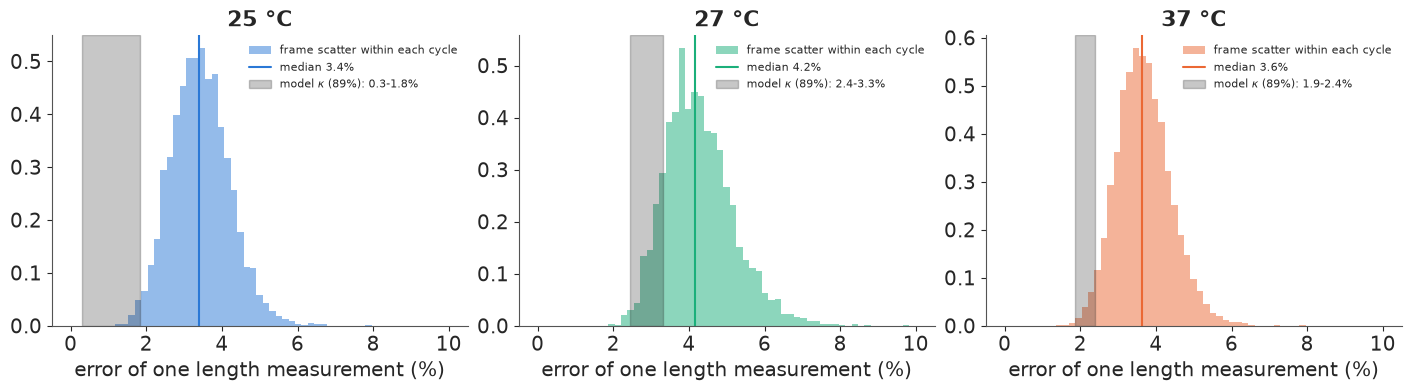

In [13]:
post = az.extract(idata_eiv, var_names=["kappa"]).values
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for t, T in enumerate(TEMPS):
    fs = cycles.loc[cycles["ok"] & (cycles.temp == T), "frame_sd"]
    axes[t].hist(100 * fs, bins=np.linspace(0, 10, 60), color=TCOL[T], alpha=0.5, density=True,
                 label="frame scatter within each cycle")
    axes[t].axvline(100 * fs.median(), color=TCOL[T], lw=1.5, label=f"median {100 * fs.median():.1f}%")
    lo, hi = np.quantile(100 * post[t], [0.055, 0.945])
    axes[t].axvspan(lo, hi, color=INK, alpha=0.25,
                    label=f"model $\\kappa$ (89%): {lo:.1f}-{hi:.1f}%")
    axes[t].set(title=f"{T} °C", xlabel="error of one length measurement (%)")
    axes[t].legend(fontsize=8)

The measurement error the lineages imply (grey band) is at the low end of the distribution of
within-cycle frame scatter (histogram), at every temperature. Using the frame scatter as the
"known" error would therefore overstate it. Section 7 checks what that would do.

## 7 · A stress test: add known noise to the real data

The errors-in-variables model should give the same $a$ whatever the image quality. We can test
that on the real data: add independent noise of sd 8% (a poorer segmentation, e.g. from phase
contrast at lower magnification) to every measured log length, and refit both models. We also
fit the errors-in-variables model with $\kappa$ **fixed** at 3.5%, the typical frame scatter, to
see what happens when the noise is "known" but wrong.

In [14]:
Y_noisy = Y + np.random.default_rng(RANDOM_SEED + 3).normal(0, 0.08, Y.shape)
idata_naive_noisy = fit(naive_model(Y_noisy, ti), "naive, +8% noise")
idata_eiv_noisy = fit(eiv_model(Y_noisy, ti), "errors-in-variables, +8% noise")
idata_eiv_k35 = fit(eiv_model(Y, ti, kappa_fixed=0.035), "errors-in-variables, kappa = 3.5%")
print(az.summary(idata_eiv_noisy, var_names=["a", "kappa"], round_to=3)
      [["mean", "sd", "ess_bulk", "r_hat"]])

naive, +8% noise: 4 s, 0 divergences, 400 tuning steps (nutpie)


errors-in-variables, +8% noise: 37 s, 0 divergences, 400 tuning steps (nutpie)


errors-in-variables, kappa = 3.5%: 37 s, 0 divergences, 400 tuning steps (nutpie)
            mean     sd  ess_bulk  r_hat
a[25]      1.105  0.037  1052.169  1.002
a[27]      0.900  0.054   602.110  1.004
a[37]      0.782  0.035   562.355  1.004
kappa[25]  0.080  0.003  1896.052  1.000
kappa[27]  0.083  0.002  2144.043  1.001
kappa[37]  0.083  0.001  2005.868  1.002


                        25    27    37
EIV, +8% noise        1.11  0.90  0.78
EIV, κ fixed at 3.5%  1.12  0.87  0.78
errors-in-variables   1.07  0.83  0.70
naive                 1.09  0.85  0.75
naive, +8% noise      0.98  0.66  0.53


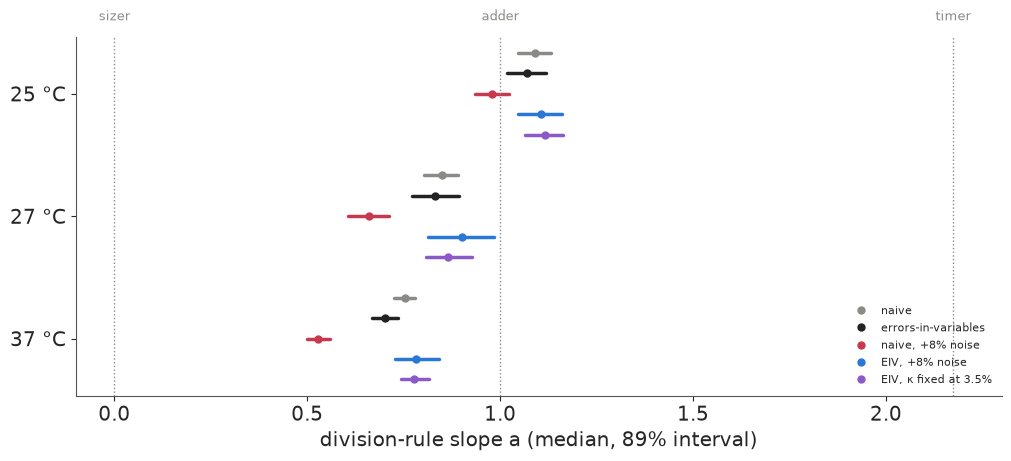

In [15]:
fits = {"naive": idata_naive, "errors-in-variables": idata_eiv,
        "naive, +8% noise": idata_naive_noisy, "EIV, +8% noise": idata_eiv_noisy,
        "EIV, κ fixed at 3.5%": idata_eiv_k35}
cols = [GREY, INK, RED, BLUE, PURPLE]
a_summ = {}
fig, ax = plt.subplots(figsize=(10, 4.5))
for j, (lab, idt) in enumerate(fits.items()):
    a_draws = az.extract(idt, var_names=["a"]).values
    for t, T in enumerate(TEMPS):
        lo, mid, hi = np.quantile(a_draws[t], [0.055, 0.5, 0.945])
        a_summ[(lab, T)] = mid
        y = t * 6 + j
        ax.plot([lo, hi], [y, y], color=cols[j], lw=2.5)
        ax.plot(mid, y, "o", color=cols[j], ms=5, label=lab if t == 0 else None)
for x, lab in [(0, "sizer"), (1, "adder"), (1 / 0.46, "timer")]:
    ax.axvline(x, color=GREY, ls=":", lw=1)
    ax.text(x, -1.6, lab, ha="center", color=GREY, fontsize=9)
ax.set_yticks([t * 6 + 2 for t in range(3)], [f"{T} °C" for T in TEMPS])
ax.invert_yaxis()
ax.set(xlabel="division-rule slope a (median, 89% interval)", xlim=(-0.1, 2.3))
ax.legend(fontsize=8, loc="lower right")
print(pd.Series(a_summ).unstack().round(2))

The stress test works as the theory says. With 8% more noise, the **naive** slope (red) falls
from about 0.75 to 0.53 at 37 °C, from 0.85 to 0.66 at 27 °C and from 1.09 to 0.98 at 25 °C:
a noisier camera would have "shown" that *E. coli* at 37 °C is half-way to a sizer. The
**errors-in-variables** model on the same degraded data (blue) estimates the total noise
($\kappa$ of 8.0-8.3%, about $\sqrt{8^2 + \kappa_0^2}$) and gives slopes of about 1.11, 0.90 and
0.78. That is not a perfect recovery - each is 0.04-0.08 above the clean-data answer (black),
with intervals about 1.5 times wider - but the naive error was three to five times larger and
pointed the other way. Model the noise, and the answer depends much less on the camera.

Fixing $\kappa$ at the frame scatter (purple) over-corrects: every slope moves up (1.12, 0.87,
0.78) because the model now attributes more of the birth-size variance to noise than the
lineages support. Errors-in-variables corrections are only as good as the error variance you
give them; here the data could estimate it, and should.

## 8 · Sizer, adder or timer? LOO over lineage windows

The posterior of $a$ already answers the question, but the three textbook rules are specific
models, and it is instructive to compare them directly. We refit the errors-in-variables model
with $\alpha$ fixed at 0 (sizer), at $\hat f$ (adder, $a = 1$) and at 1 (timer), keeping
everything else - including the measurement error - free, and compare by PSIS-LOO. The unit left
out is one **window** (eight generations of one mother), the natural exchangeable unit of this
likelihood.

In [16]:
def window_loo(idata):
    """PSIS-LOO with one log-likelihood value per window (the three temperatures concatenated)."""
    ll = np.concatenate([idata.log_likelihood[f"y{T}"].values for T in TEMPS], axis=-1)
    tree = xr.DataTree.from_dict({"posterior": idata.posterior.to_dataset(),
                                  "log_likelihood": xr.Dataset({"y": (("chain", "draw", "window"), ll)})})
    return az.loo(tree, pointwise=True)


loo = {"free a": window_loo(idata_eiv)}
for rule in ["sizer", "adder", "timer"]:
    m = eiv_model(Y, ti, rule=rule)
    idt = fit(m, rule, target_accept=0.9, draws=500)          # 2,000 draws suffice for LOO here
    pm.compute_log_likelihood(idt, model=m, progressbar=False)
    loo[rule] = window_loo(idt)
    kap = az.extract(idt, var_names=["kappa"]).values.mean(axis=1)
    print(f"   posterior mean kappa: {dict(zip(TEMPS, kap.round(3).tolist()))}")
    del idt["log_likelihood"]
    if rule == "adder":
        idata_adder = idt
    del idt
del idata_eiv["log_likelihood"]
for v in loo.values():
    v.log_weights = None
cmp = az.compare(loo, round_to=1)
d_adder = np.asarray(loo["adder"].elpd_i) - np.asarray(loo["free a"].elpd_i)
wt = np.concatenate([np.full((ti == t).sum(), T) for t, T in enumerate(TEMPS)])  # window order
print("adder minus free, elpd by temperature:",
      {T: round(float(d_adder[wt == T].sum()), 1) for T in TEMPS})
print({k: f"max k-hat {float(np.max(v.pareto_k)):.2f}" for k, v in loo.items()})
cmp

sizer: 19 s, 0 divergences, 400 tuning steps (nutpie)


   posterior mean kappa: {25: 0.01, 27: 0.024, 37: 0.019}


adder: 24 s, 1 divergences, 400 tuning steps (nutpie)


   posterior mean kappa: {25: 0.009, 27: 0.034, 37: 0.03}


timer: 29 s, 0 divergences, 400 tuning steps (nutpie)


   posterior mean kappa: {25: 0.058, 27: 0.06, 37: 0.054}
adder minus free, elpd by temperature: {25: -1.5, 27: -8.1, 37: -83.5}
{'free a': 'max k-hat 0.42', 'sizer': 'max k-hat 0.30', 'adder': 'max k-hat 0.25', 'timer': 'max k-hat 0.24'}


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
free a,0,0.0,0.0,NaN,,,32.1,29402.8,211.3,0.9
adder,1,-93.1,14.9,1.0,,,28.3,29309.7,211.0,0.1
sizer,2,-1342.3,55.9,1.0,,,29.8,28060.5,219.3,0.0
timer,3,-2771.4,61.8,1.0,,,23.8,26631.4,215.7,0.0


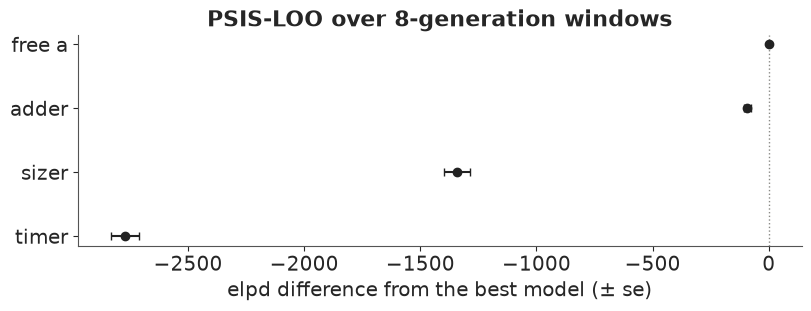

In [17]:
fig, ax = plt.subplots(figsize=(8, 3))
order = cmp.index.tolist()
ax.errorbar(cmp["elpd_diff"], range(len(order)), xerr=cmp["dse"], fmt="o", color=INK, capsize=3)
ax.set_yticks(range(len(order)), order)
ax.invert_yaxis()
ax.axvline(0, color=GREY, ls=":", lw=1)
ax.set(xlabel="elpd difference from the best model (± se)", title="PSIS-LOO over 8-generation windows");

The free-slope model wins, the adder is next (about 90 elpd behind, with a standard error of
about 15), the sizer is far behind (about 1,300), and the timer is last (about 2,800). All Pareto
$k$ values are below 0.5 (printed). Two cautions in reading this. First, with about 2,000
windows, LOO can distinguish $a = 0.7$ from $a = 1$ easily; "the free model wins" says the data
are not *exactly* an adder at every temperature, not that the adder is a bad description - it
is much closer than either alternative. Second, splitting the difference by temperature
(printed) shows where the adder loses: almost all of it at 37 °C, some at 27 °C, and nearly
nothing at 25 °C. Note also how the timer tries to survive: its $\kappa$ jumps to 5-6%, i.e. it
explains the size correction it cannot produce as measurement error.

## 9 · Checking the adder's other predictions

An adder makes predictions beyond the slope: the added size should not depend on birth size;
its spread should be the same for small and large newborns; and birth sizes along a lineage
should be correlated by about $f a \approx 0.46$ per generation. The measured versions of all
three are distorted by measurement noise, so we check them with **posterior predictive**
simulations, which carry the same noise, from the free model and from the adder.

observed:
     corr(birth, added length)  CV of added length  \
25                      0.023               0.335   
27                     -0.102               0.189   
37                     -0.159               0.174   

    birth-length autocorrelation, lag 1  
25                                0.495  
27                                0.427  
37                                0.375  


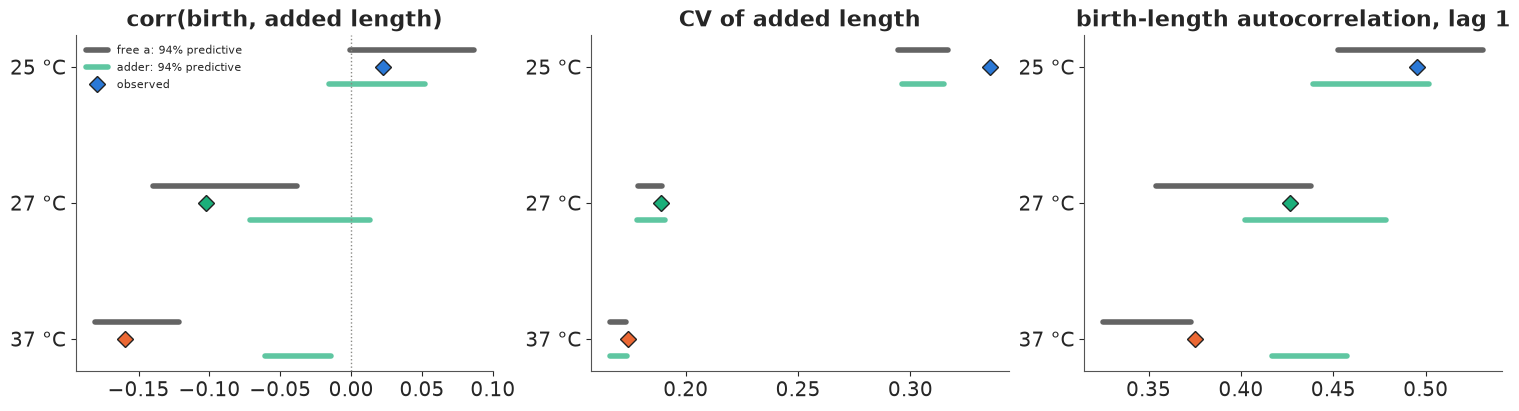

In [18]:
def lineage_stats(Yw, tiw):
    """Per temperature: corr(birth, added length), CV of added length, lag-1 autocorr of birth."""
    Sb, Sd = np.exp(Yw[..., 0::2]), np.exp(Yw[..., 1::2])
    out = []
    for t in range(3):
        sb, sd = Sb[..., tiw == t, :], Sd[..., tiw == t, :]
        dl = sd - sb
        x, y = sb.reshape(*sb.shape[:-2], -1), dl.reshape(*dl.shape[:-2], -1)
        xc, yc = x - x.mean(-1, keepdims=True), y - y.mean(-1, keepdims=True)
        corr = (xc * yc).mean(-1) / (xc.std(-1) * yc.std(-1))
        cv = y.std(-1) / y.mean(-1)
        b0 = sb[..., :-1] - sb.mean((-2, -1), keepdims=True)
        b1 = sb[..., 1:] - sb.mean((-2, -1), keepdims=True)
        ac = (b0 * b1).mean((-2, -1)) / (sb.var((-2, -1)))
        out.append(np.stack([corr, cv, ac], -1))
    return np.stack(out, -2)                                   # (..., temp, stat)


def ppc_windows(idata, model, n=200):
    thin = idata.isel(draw=slice(None, None, idata.posterior.sizes["draw"] * 4 // n))
    pp = pm.sample_posterior_predictive(thin, model=model, random_seed=RANDOM_SEED,
                                        progressbar=False)
    Yr = np.zeros((pp.posterior_predictive.sizes["chain"] * pp.posterior_predictive.sizes["draw"],
                   *Y.shape))
    for t, T in enumerate(TEMPS):
        Yr[:, ti == t] = pp.posterior_predictive[f"y{T}"].values.reshape(-1, (ti == t).sum(), 2 * NW)
    return Yr


obs_stats = lineage_stats(Y, ti)
rep = {"free a": lineage_stats(ppc_windows(idata_eiv, m_free), ti),
       "adder": lineage_stats(ppc_windows(idata_adder, eiv_model(Y, ti, "adder")), ti)}
names = ["corr(birth, added length)", "CV of added length", "birth-length autocorrelation, lag 1"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for s, ax in enumerate(axes):
    for t, T in enumerate(TEMPS):
        for j, (lab, r) in enumerate(rep.items()):
            lo, hi = np.quantile(r[:, t, s], [0.03, 0.97])
            y = t + (j - 0.5) * 0.25
            ax.plot([lo, hi], [y, y], color=[INK, AQUA][j], lw=4, alpha=0.7,
                    label=f"{lab}: 94% predictive" if t == 0 else None)
        ax.plot(obs_stats[t, s], t, "D", color=TCOL[T], ms=8, mec=INK,
                label="observed" if t == 0 else None)
    ax.set_yticks(range(3), [f"{T} °C" for T in TEMPS])
    ax.invert_yaxis()
    ax.set(title=names[s])
axes[0].axvline(0, color=GREY, ls=":", lw=1)
axes[0].legend(fontsize=8)
print("observed:\n", pd.DataFrame(obs_stats, index=TEMPS, columns=names).round(3))

Diamonds are the observed statistics, bars the 94% posterior predictive intervals (dark: free
slope; green: adder), each simulated with the model's own measurement noise.

- **Added length vs birth length** (left). Observed correlations are 0.02 at 25 °C, -0.10 at
  27 °C and -0.16 at 37 °C. The adder, *including* its measurement noise, predicts correlations
  between about -0.07 and +0.05: it misses 37 °C clearly and 27 °C just; the free model
  reproduces all three. So the negative correlation is not a noise artefact here: the noise is
  too small to create it.
- **Spread of the added length** (middle): at 27 and 37 °C both models reproduce the CV of
  $\Delta$; this statistic cannot tell the rules apart. At 25 °C *both* miss: the observed CV
  (0.34) is above what either predicts (about 0.29-0.32). The 25 °C data have heavier tails than
  a Gaussian model allows (the widest birth-size distribution in the summary table), a
  misspecification shared by both rules.
- **Memory** (right): birth-length autocorrelation from one generation to the next is 0.38-0.50.
  The free model reproduces it (at 37 °C at the edge of its interval); the adder overshoots at
  37 °C, as its $f a = 0.46$ is larger than the fitted $\alpha = 0.32$.

The adder fails where its slope failed (37 °C clearly, 27 °C marginally) and passes at 25 °C.

## 10 · Growth-rate variability: lineages, partial pooling, and why fast growers divide early

Size control is only half of the cell cycle. The other half is growth: how much does the
exponential growth rate $\lambda$ vary between cycles, and between mothers? Mothers in
different channels of the chip could differ (local flow, nutrient supply, their own history).
A hierarchical model separates the two sources:

$$\lambda_{i} \sim N(\mu_T + u_{\ell(i)},\ \sigma_T), \qquad u_\ell \sim N(0, \tau_T),$$

for cycle $i$ of mother $\ell$ at temperature $T$. The **intraclass correlation**
$\tau_T^2 / (\tau_T^2 + \sigma_T^2)$ is the share of growth-rate variance that is a stable
property of the mother.

In [19]:
gl = good.copy()
gl["lam_h"] = 60 * gl["lam"]                                   # per hour: parameters of order 1
lin_codes, lin_names = pd.factorize(gl["lineage"])
lin_temp = gl.groupby(lin_codes)["temp"].first().to_numpy()
lin_ti = np.searchsorted(TEMPS, lin_temp)
with pm.Model(coords={"temp": TEMPS, "lineage": lin_names}) as m_lam:
    mu = pm.Normal("mu", 1.0, 0.5, dims="temp")
    tau = pm.HalfNormal("tau", 0.1, dims="temp")
    sigma = pm.HalfNormal("sigma", 0.3, dims="temp")
    z = pm.Normal("z", 0, 1, dims="lineage")
    lam_lin = pm.Deterministic("lam_lineage", mu[lin_ti] + tau[lin_ti] * z, dims="lineage")
    pm.Normal("lam", lam_lin[lin_codes], sigma[lin_ti][lin_codes], observed=gl["lam_h"].to_numpy())
    pm.Deterministic("icc", tau**2 / (tau**2 + sigma**2), dims="temp")
idata_lam = fit(m_lam, "hierarchical growth rates")
print(az.summary(idata_lam, var_names=["mu", "tau", "sigma", "icc"], round_to=4))
print(f"max r_hat over the lineage effects: {float(az.rhat(idata_lam, var_names=['z'])['z'].max()):.3f}")


def lag1(df, col):
    out = {}
    for T in TEMPS:
        h = df[df.temp == T].sort_values(["lineage", "cycle"])
        same = (h["lineage"].values[1:] == h["lineage"].values[:-1]) & (np.diff(h["cycle"].values) == 1)
        x = h[col].values
        xm = x - h.groupby("lineage")[col].transform("mean").values   # within-mother deviations
        out[T] = np.corrcoef(xm[:-1][same], xm[1:][same])[0, 1]
    return out


print("mother-to-daughter correlation of growth rate (within mothers):",
      {T: round(float(v), 3) for T, v in lag1(gl, "lam").items()})
n_cyc = gl.groupby("lineage").size().median()
tau_m, sig_m = (az.extract(idata_lam, var_names=[v]).values.mean(axis=1) for v in ["tau", "sigma"])
print(f"pooling weight on a mother's own mean ({n_cyc:.0f} cycles):",
      dict(zip(TEMPS, (tau_m**2 / (tau_m**2 + sig_m**2 / n_cyc)).round(2).tolist())))

hierarchical growth rates: 5 s, 0 divergences, 400 tuning steps (nutpie)
             mean      sd  eti89_lb  eti89_ub   ess_bulk   ess_tail   r_hat  \
mu[25]     0.7276  0.0017    0.7249    0.7304  2050.4714  2502.9576  0.9999   
mu[27]     0.8915  0.0016    0.8890    0.8942  4278.1821  3136.8461  1.0004   
mu[37]     1.5169  0.0020    1.5138    1.5200  2156.9590  2400.3013  1.0024   
tau[25]    0.0115  0.0014    0.0094    0.0139  1613.5939  2185.2383  1.0028   
tau[27]    0.0081  0.0018    0.0052    0.0111  1718.4115  2154.1420  1.0016   
tau[37]    0.0211  0.0016    0.0187    0.0237  1433.4012  2023.4550  1.0018   
sigma[25]  0.0565  0.0006    0.0556    0.0575  7769.6520  2969.1200  1.0024   
sigma[27]  0.0717  0.0009    0.0703    0.0731  7493.2513  3073.3988  1.0014   
sigma[37]  0.1020  0.0007    0.1009    0.1031  7492.4046  3061.4846  1.0011   
icc[25]    0.0403  0.0098    0.0268    0.0575  1609.2462  2089.1892  1.0027   
icc[27]    0.0132  0.0058    0.0053    0.0235  1713.5543  

max r_hat over the lineage effects: 1.006
mother-to-daughter correlation of growth rate (within mothers): {25: 0.187, 27: 0.175, 37: 0.132}
pooling weight on a mother's own mean (66 cycles): {25: 0.73, 27: 0.46, 37: 0.74}


Sampling is clean (printed: no divergences, r_hat at most 1.01; rates are modelled per hour
to keep all parameters of order one). Growth rates are 0.73, 0.89 and 1.52 per hour (0.0121,
0.0149 and 0.0253 per minute) at 25, 27 and 37 °C. The cycle-to-cycle sd $\sigma_T$ is 7-8% of
the mean; the mother-to-mother sd $\tau_T$ is a tenth to a fifth of that, so the intraclass
correlation is only 1-4%. Mothers in different channels grow at nearly the same rate; what
varies is the cycle. Partial pooling still matters for each mother's own rate: with about 65
cycles per mother, its estimate puts a weight of roughly 0.5-0.75 on its own mean and the rest on
the temperature mean (printed). The within-mother correlation between consecutive cycles is
0.13-0.19 (printed): larger than a stable per-mother rate explains (that is removed by
subtracting each mother's mean), so growth rate has a short **memory** from mother to daughter
cycle that this model does not describe (exercise 3).

Finally, a well-known correlation: cycles that grow fast are short. Is that a separate rule, or a
consequence of size control? If division is triggered by size, a fast grower reaches its
division size sooner, so $\tau = \log(S_d/S_b)/\lambda$ is shorter. We simulate generation times
by combining the size-control model's predictive birth and division sizes with growth rates
drawn from the hierarchical model (independent of size), and compare the predicted correlation
between $\lambda$ and $\tau$ with the observed one.

observed corr(lambda, tau): {25: -0.38, 27: -0.334, 37: -0.4}
predicted (median): {25: -0.303, 27: -0.445, 37: -0.409}


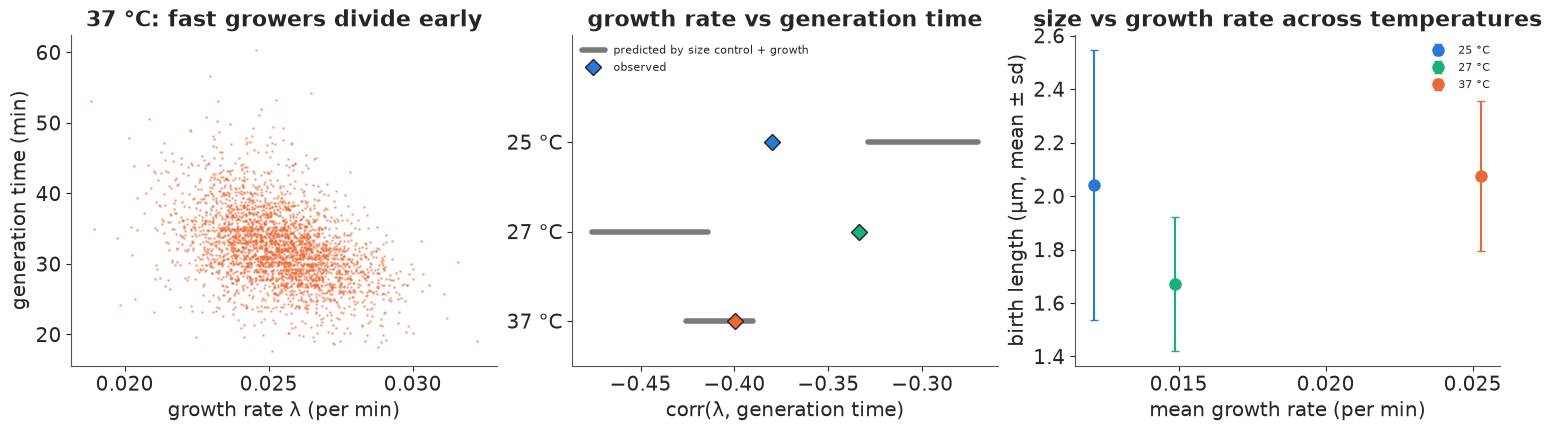

In [20]:
ppY = ppc_windows(idata_eiv, m_free, n=100)
lam_post = az.extract(idata_lam, var_names=["lam_lineage"], num_samples=ppY.shape[0],
                      random_seed=RANDOM_SEED).values.T                  # (draws, lineage)
sig_post = az.extract(idata_lam, var_names=["sigma"], num_samples=ppY.shape[0],
                      random_seed=RANDOM_SEED).values.T
win_lin = pd.Index(lin_names).get_indexer(win_lineage)
assert (win_lin >= 0).all()
prng = np.random.default_rng(RANDOM_SEED + 4)
pred_corr = np.zeros((ppY.shape[0], 3))
for s in range(ppY.shape[0]):
    lam_rep = (lam_post[s, win_lin][:, None]
               + sig_post[s, ti][:, None] * prng.normal(size=(len(Y), NW))) / 60   # per minute
    tau_rep = (ppY[s][:, 1::2] - ppY[s][:, 0::2]) / lam_rep
    for t in range(3):
        pred_corr[s, t] = np.corrcoef(lam_rep[ti == t].ravel(), tau_rep[ti == t].ravel())[0, 1]
obs_corr = [np.corrcoef(good.loc[good.temp == T, "lam"], good.loc[good.temp == T, "gen_time"])[0, 1]
            for T in TEMPS]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
g37 = good[good.temp == 37].sample(3000, random_state=RANDOM_SEED)
axes[0].plot(g37["lam"], g37["gen_time"] + prng.uniform(-0.4, 0.4, len(g37)), ".", ms=2,
             color=ORANGE, alpha=0.4)
axes[0].set(xlabel="growth rate λ (per min)", ylabel="generation time (min)",
            title="37 °C: fast growers divide early")
for t, T in enumerate(TEMPS):
    lo, hi = np.quantile(pred_corr[:, t], [0.03, 0.97])
    axes[1].plot([lo, hi], [t, t], color=INK, lw=4, alpha=0.6,
                 label="predicted by size control + growth" if t == 0 else None)
    axes[1].plot(obs_corr[t], t, "D", color=TCOL[T], ms=8, mec=INK, label="observed" if t == 0 else None)
axes[1].set_yticks(range(3), [f"{T} °C" for T in TEMPS])
axes[1].set_ylim(2.5, -1.2)
axes[1].set(xlabel="corr(λ, generation time)", title="growth rate vs generation time")
axes[1].legend(fontsize=8, loc="upper left")
axes[0].locator_params(axis="x", nbins=5)
axes[2].locator_params(axis="x", nbins=5)
lam_mean = az.extract(idata_lam, var_names=["mu"]).values / 60
for t, T in enumerate(TEMPS):
    lb = good.loc[good.temp == T, "Lb"]
    axes[2].errorbar(lam_mean[t].mean(), lb.mean(), yerr=lb.std(), fmt="o", color=TCOL[T], ms=8,
                     capsize=3, label=f"{T} °C")
axes[2].set(xlabel="mean growth rate (per min)", ylabel="birth length (µm, mean ± sd)",
            title="size vs growth rate across temperatures")
axes[2].legend(fontsize=8)
print("observed corr(lambda, tau):", dict(zip(TEMPS, np.round(obs_corr, 3).tolist())))
print("predicted (median):", dict(zip(TEMPS, np.round(np.median(pred_corr, 0), 3).tolist())));

Left: at 37 °C, cycles with a higher growth rate are shorter (generation times come in whole
minutes, the frame interval; points are jittered). Middle: the observed correlation between
growth rate and generation time (diamonds) is -0.33 to -0.40. The size-control model plus growth
rates drawn independently of size (bars) predicts a correlation of the same sign and size, -0.3
to -0.45, without any rule that links growth rate to cycle duration: fast growers divide early
largely *because* division is triggered by size. The match is not exact: right at 37 °C, too
weak at 25 °C and too strong at 27 °C. The prediction ignores the growth-rate memory found
above and the error in each cycle's fitted rate, both of which change this correlation.

Right: mean birth length against mean growth rate across temperatures. Across *nutrient*
conditions bacteria are larger the faster they grow (the "growth law" going back to
Schaechter, Maaløe and Kjeldgaard 1958). Temperature is a different axis: here, growth rate
doubles between 25 and 37 °C while birth length changes by about 10% and not monotonically
(27 °C is the smallest). With one experiment per temperature we cannot separate a temperature
effect from day-to-day differences in imaging and calibration, so we do not read more into it.

## Summary

- The **noisy linear map** $S_d = a S_b + b + \xi$ contains the sizer ($a = 0$), adder ($a = 1$)
  and timer ($a \approx 2$); with division it makes birth size an AR(1) process along a lineage,
  stable only for $fa < 1$ (section 1).
- **Regression dilution**: measurement error in birth size flattens the slope by the reliability
  $R$ and makes the added size anti-correlated with birth size, both pointing towards "sizer"
  (section 2). More data does not help; modelling the noise does.
- In Tanouchi et al.'s mother-machine data the **naive** slope is about 1.09, 0.85 and 0.75 at 25,
  27 and 37 °C (section 4). An **errors-in-variables** model of eight generations at a time - a
  closed-form 16-dimensional normal - estimates the single-measurement error from the lineages'
  own memory: 1-3% of the length, less than the frame scatter (sections 5-6). With noise this
  small the correction is small: $a \approx 1.07$, 0.83, 0.70.
- **Stress test**: adding 8% noise to the real data pulls the naive slope at 37 °C to 0.53;
  the errors-in-variables model estimates the added noise and returns 0.78 (clean: 0.70). Fixing
  the noise at a wrong (too large) value over-corrects (section 7).
- **LOO** ranks free slope > adder >> sizer >> timer; posterior predictive checks show the adder
  fits 25 °C but misses the negative added-size/birth-size correlation at 37 °C (and marginally
  at 27 °C), which is too large to be a noise artefact (sections 8-9). On these data *E. coli*
  MC4100 in LB is close to an adder at 25 °C and between adder and sizer at 37 °C.
- Growth rates vary from cycle to cycle, little between mothers (intraclass correlation 1-4%),
  with a short mother-to-daughter memory; the negative correlation between growth rate and
  generation time follows, to a first approximation, from size control plus exponential growth
  (section 10).

## Try it yourself

1. **Whole lineages.** Replace the windows by a Kalman filter along each mother's full history
   (state: true log birth size and the mother's intercept; `pytensor.scan` over generations,
   vectorised over mothers; flagged cycles become missing observations). Does $a$ change when
   the intercept is constant for a mother's whole life rather than per window? What does that
   say about slow drift in these movies?
2. **Nonlinear size control.** The linear map is a local approximation. Let the slope depend on
   birth size (e.g. $d = \alpha(b)\, b + c$ with $\alpha(b)$ linear in $b$) and ask whether large
   newborns (after a filamentation) are corrected more strongly than small ones. How do the
   flagged cycles, left out here, change the answer?
3. **Growth-rate memory.** Section 10 found that consecutive cycles of a mother have correlated
   growth rates beyond a stable per-mother rate. Fit an AR(1) model for $\lambda$ along lineages,
   with measurement error on each cycle's fitted rate (its standard error from the exponential
   fit). How long is the memory, in generations? Feed it into the prediction of section 10's
   growth-rate/generation-time correlation: does the mismatch at 25 and 27 °C shrink?